<a href="https://colab.research.google.com/github/elvirkaaa/startup-failure-analysis/blob/main/Code%20of%20analysis%20of%203rddataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

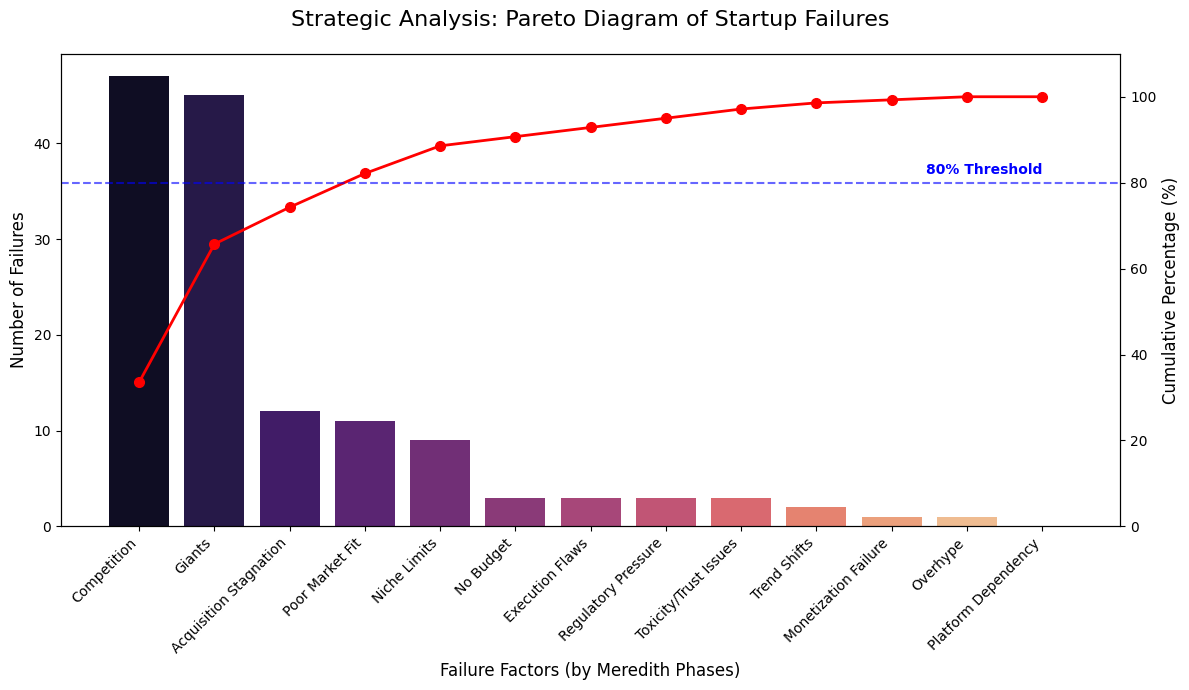

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('67f16907591e1.csv')


risk_columns = [
    'Giants', 'No Budget', 'Competition', 'Poor Market Fit',
    'Acquisition Stagnation', 'Platform Dependency', 'Monetization Failure',
    'Niche Limits', 'Execution Flaws', 'Trend Shifts',
    'Toxicity/Trust Issues', 'Regulatory Pressure', 'Overhype'
]


failure_counts = df[risk_columns].sum().sort_values(ascending=False)


def draw_pareto(counts):
    df_pareto = pd.DataFrame({'Reason': counts.index, 'Frequency': counts.values})
    df_pareto['CumulativePercentage'] = (df_pareto['Frequency'].cumsum() / df_pareto['Frequency'].sum()) * 100

    fig, ax1 = plt.subplots(figsize=(12, 7))


    sns.barplot(x='Reason', y='Frequency', data=df_pareto, ax=ax1, hue='Reason', palette='magma', legend=False)


    ax1.set_xticks(range(len(df_pareto)))
    ax1.set_xticklabels(df_pareto['Reason'], rotation=45, ha='right')

    ax1.set_title('Strategic Analysis: Pareto Diagram of Startup Failures', fontsize=16, pad=20)
    ax1.set_ylabel('Number of Failures', fontsize=12)
    ax1.set_xlabel('Failure Factors (by Meredith Phases)', fontsize=12)


    ax2 = ax1.twinx()
    ax2.plot(df_pareto['Reason'], df_pareto['CumulativePercentage'], color='red', marker='o', ms=7, linewidth=2, label='Cumulative %')


    ax2.axhline(80, color='blue', linestyle='--', alpha=0.6)
    ax2.text(len(df_pareto)-1, 82, '80% Threshold', color='blue', fontweight='bold', ha='right')

    ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
    ax2.set_ylim(0, 110)

    plt.tight_layout()

    plt.savefig('pareto_failure_analysis.png', dpi=300)
    plt.show()


draw_pareto(failure_counts)

plt.savefig('pareto_analysis.png', dpi=300, bbox_inches='tight')